In [ ]:
import pandas as pd
import numpy as np
import os

data = pd.read_csv(os.path.join("..", "wide_sta_observations.csv"), parse_dates=["period_date"])
data.rename(columns={"period_date": "date"}, inplace=True)
metadata = pd.read_csv(os.path.join("..", "all_metadata.csv"))

target_variable = "66" 
lags = list(range(-2, 3)) 

train_start_date = "2000-01-01"
test_start_date = "2018-03-01" 
test_end_date = "2023-12-01"

test = data.loc[
    (data.date >= train_start_date) & 
    (data.date <= test_end_date)
].reset_index(drop=True)

print(f"Duomenų rėžių patikra: Nuo {test.date.min()} iki {test.date.max()}")

Duomenų rėžių patikra: Nuo 2000-01-01 00:00:00 iki 2023-12-01 00:00:00


In [ ]:
# kodas iš: https://github.com/dhopp1/nowcasting_benchmark/tree/main/methodologies

# Generuojami suvėlinti duomenų rinkiniai testavimui pagal informacijos prieinamumo laikotarpius (vintages)
def gen_lagged_data(metadata, data, last_date, lag):
    lagged_data = data.loc[data.date <= last_date, :].reset_index(drop=True)
    metadata['series_id'] = metadata['series_id'].astype(str)
    for col in lagged_data.columns[1:]:
        pub_lag = metadata.loc[metadata.series_id == col, "months_lag"].values[0] # Konkretaus kintamojo paskelbimo vėlavimas
        # Reikšmės paslepiamos (NaN) atsižvelgiant į paskelbimo vėlavimą ir pasirinktą modeliavimo momentą (lag)
        lagged_data.loc[(len(lagged_data) - pub_lag + lag) :, col] = np.nan

    return lagged_data

# Ankstenių mėnesių reikšmių įtraukimas (kaip atskiri kintamieji)
def flatten_data(data, target_variable, n_lags):
    flattened_data = data.loc[~pd.isna(data[target_variable]), :]
    orig_index = flattened_data.index
    for i in range(1, n_lags + 1):
        lagged_indices = orig_index - i
        lagged_indices = lagged_indices[lagged_indices >= 0]
        tmp = data.loc[lagged_indices, :]
        tmp.date = tmp.date + pd.DateOffset(months=i)
        tmp = tmp.drop([target_variable], axis=1)
        tmp.columns = [j + "_" + str(i) if j != "date" else j for j in tmp.columns]
        flattened_data = flattened_data.merge(tmp, how="left", on="date")

    return flattened_data

# Praleistų reikšmių užpildymas naudojant mokymo rinkinio vidurkį
def mean_fill_dataset(training, test):
    mean_dict = {}
    for col in training.columns[1:]:
        mean_dict[col] = np.nanmean(training[col])
    filled = test.copy()
    for col in training.columns[1:]:
        filled.loc[pd.isna(filled[col]), col] = mean_dict[col]
    return filled

In [3]:
dates = (
        pd.date_range(test_start_date, test_end_date, freq="3MS")
        .strftime("%Y-%m-%d")
        .tolist()
    )

actuals = list(test.loc[test.date.isin(dates), target_variable].values)

C:\Users\MigleV\AppData\Local\Temp\ipykernel_19952\32520634.py:7: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  actuals = list(test.loc[test.date.isin(dates), target_variable].values)


# Paieškos gardelė

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

train_data = test.loc[test.date < test_start_date].copy()

# Istorinis gylis
lags_to_test = [3, 4, 5, 6, 7, 8, 9] 
best_overall_rmse = float('inf')
best_overall_params = None
best_overall_lags = None

tscv = TimeSeriesSplit(n_splits=5)

for nl in lags_to_test:
    print(f"--- Testuojamas n_lags: {nl} ---")
    
    df_flat = flatten_data(train_data, target_variable, n_lags=nl)
    df_model = df_flat.loc[df_flat.date.dt.month.isin([3, 6, 9, 12]), :].dropna(subset=[target_variable])

    X_gs = df_model.drop(["date", target_variable], axis=1)
    X_gs = X_gs.dropna(axis=1, how='all')
    y_gs = df_model[target_variable]

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()), 
        ('enet', ElasticNet(random_state=42, max_iter=20000, selection='random')) 
    ])

    param_grid = {
    'enet__alpha': [
        1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4,
        1e-3, 5e-3, 0.01, 0.05, 0.1, 0.3,
        0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0
    ],
    'enet__l1_ratio': [
        0.0, 0.001, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3,
        0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 0.95, 0.99, 0.999, 1.0
    ]
}

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        verbose=0,
        n_jobs=-1
    )
    
    grid_search.fit(X_gs, y_gs)
    
    current_rmse = abs(grid_search.best_score_)
    print(f"Geriausias RMSE su {nl} lagais: {current_rmse:.4f}")

    if current_rmse < best_overall_rmse:
        best_overall_rmse = current_rmse
        best_overall_params = grid_search.best_params_
        best_overall_lags = nl

print("\n" + "="*30)
print(f"REZULTATAI:")
print(f"Geriausias n_lags: {best_overall_lags}")
print(f"Geriausi modelio parametrai: {best_overall_params}")
print(f"RMSE: {best_overall_rmse:.4f}")

--- Testuojamas n_lags: 3 ---
Geriausias RMSE su 3 lagais: 1.6236
--- Testuojamas n_lags: 4 ---
Geriausias RMSE su 4 lagais: 1.6041
--- Testuojamas n_lags: 5 ---
Geriausias RMSE su 5 lagais: 1.5992
--- Testuojamas n_lags: 6 ---
Geriausias RMSE su 6 lagais: 1.6194
--- Testuojamas n_lags: 7 ---
Geriausias RMSE su 7 lagais: 1.6465
--- Testuojamas n_lags: 8 ---
Geriausias RMSE su 8 lagais: 1.6532
--- Testuojamas n_lags: 9 ---
Geriausias RMSE su 9 lagais: 1.6521

REZULTATAI:
Geriausias n_lags: 5
Geriausi modelio parametrai: {'enet__alpha': 20.0, 'enet__l1_ratio': 0.001}
RMSE: 1.5992


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

enet_clean_params = {k.replace('enet__', ''): v for k, v in best_overall_params.items()}
pred_dict_enet = {k: [] for k in lags}

for date in dates:
    # Paruošiame mokymo duomenis
    train = test.loc[test.date <= str(pd.to_datetime(date) - pd.tseries.offsets.DateOffset(months=3))[:10], :].copy()
    transformed_train = mean_fill_dataset(train, train)
    transformed_train = flatten_data(transformed_train, target_variable, best_overall_lags)
    transformed_train = transformed_train.loc[transformed_train.date.dt.month.isin([3, 6, 9, 12]), :].dropna(subset=[target_variable]).reset_index(drop=True)
    
    model = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()), 
        ('enet', ElasticNet(**enet_clean_params, random_state=42, max_iter=10000, selection='random'))
    ])
    
    x = transformed_train.drop(["date", target_variable], axis=1)
    y = transformed_train[target_variable]
    model.fit(x, y)
    
    for lag in lags:
        # Generuojame konkretaus informacijos prieinamumo duomenis
        tmp_data = gen_lagged_data(metadata, test, date, lag)
        tmp_data = mean_fill_dataset(train, tmp_data) 
        tmp_data = flatten_data(tmp_data, target_variable, best_overall_lags)
        
        x_test = tmp_data.loc[tmp_data.date == date, x.columns]
        
        pred = model.predict(x_test)[0] if not x_test.empty else np.nan
        pred_dict_enet[lag].append(pred)

In [19]:
# METRIKŲ SKAIČIAVIMAS
results_enet = []

for lag in lags:
    valid_indices = ~np.isnan(pred_dict_enet[lag])
    y_true = np.array(actuals)[valid_indices]
    y_pred = np.array(pred_dict_enet[lag])[valid_indices]
    
    if len(y_true) > 0:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        
        results_enet.append({
            "Vintage (Lag)": lag,
            "RMSE": rmse,
            "MAE": mae,
            "N_Predictions": len(y_true)
        })
    else:
        results_enet.append({"Vintage (Lag)": lag, "RMSE": np.nan, "MAE": np.nan, "N_Predictions": 0})

performance_df_enet = pd.DataFrame(results_enet)
print(performance_df_enet.round(5).to_string(index=False))

 Vintage (Lag)    RMSE     MAE  N_Predictions
            -2 2.61339 1.73301             24
            -1 2.51122 1.63430             24
             0 2.47361 1.58557             24
             1 2.48792 1.59895             24
             2 2.48978 1.60645             24


In [20]:
import json

# Saugome modelio prognozes
df_preds_enet = pd.DataFrame(pred_dict_enet).add_prefix('lag_')
df_preds_enet['date'] = dates
df_preds_enet['actual'] = actuals
df_preds_enet.to_csv('predictions_elasticnet.csv', index=False)

# Saugome optimalius parametrus
with open('best_params_elasticnet.json', 'w') as f:
    json.dump({"optimal_n_lags": best_overall_lags, "best_enet_parameters": best_overall_params}, f, indent=4)

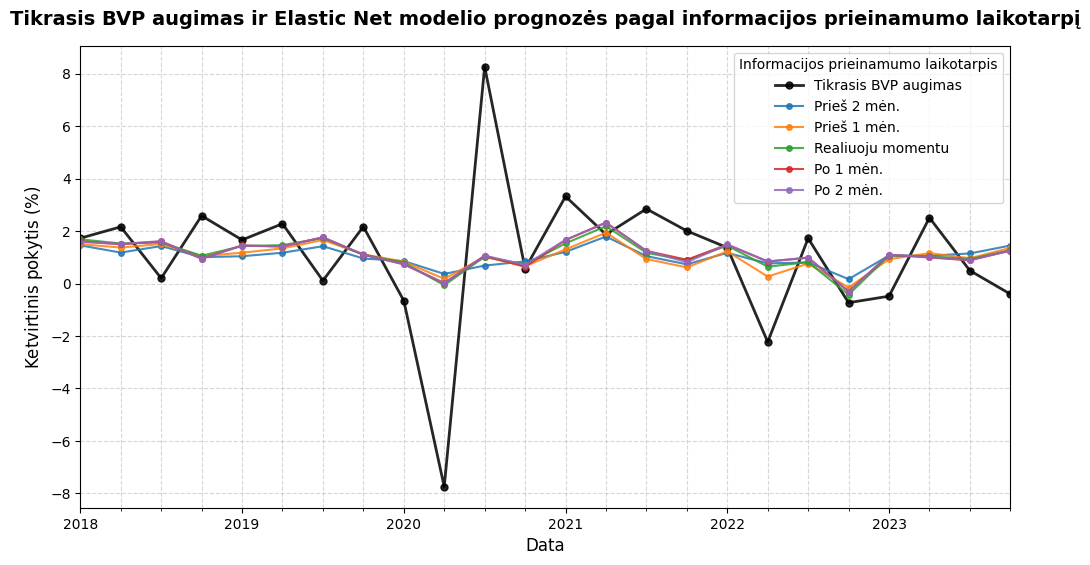

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

pred_dict_enet = pd.read_csv('predictions_elasticnet.csv')

actuals = pred_dict_enet['actual']
dates = pred_dict_enet['date']

df_plot_enet = pd.DataFrame({
    "Tikrasis BVP augimas": actuals.values, 
    "Prieš 2 mėn.": pred_dict_enet['lag_-2'].values, 
    "Prieš 1 mėn.": pred_dict_enet['lag_-1'].values, 
    "Realiuoju laiku": pred_dict_enet['lag_0'].values,
    "Po 1 mėn.": pred_dict_enet['lag_1'].values,
    "Po 2 mėn.": pred_dict_enet['lag_2'].values
}, index=pd.to_datetime(dates))

# Grafikas
colors = ['black', 'C0', 'C1', 'C2', 'C3', 'C4']

ax = df_plot_enet.plot(
    figsize=(12, 5), 
    color=colors, 
    marker='o', 
    markersize=4, 
    linewidth=1.5, 
    alpha=0.85
)

ax.lines[0].set_linewidth(2)       
ax.lines[0].set_markersize(5)        

ax.lines[1].set_linestyle('-')       
ax.lines[2].set_linestyle('-')       
ax.lines[3].set_linestyle('-')      
ax.lines[4].set_linestyle('-')      
ax.lines[5].set_linestyle('-')      

plt.title("Tikrasis BVP augimas ir Elastic Net modelio prognozės pagal informacijos prieinamumo laikotarpį", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Ketvirtinis pokytis ($\\%$)", fontsize=14)
plt.xlabel("Data", fontsize=14)

# Legenda
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(title="Informacijos prieinamumo laikotarpis", loc='lower right', fontsize=14, title_fontsize=14, ncol=2, labelspacing=0.5, handlelength=1.5)
ax.tick_params(axis='both', which='major', labelsize=14)

plt.savefig('elasticnet_nowcast_comparison.png', dpi=300, bbox_inches='tight')
plt.show()